# EDA: Feature Parameter Sweep (d_s, d_p, d_f, l_s, l_p, l_f)

**Goal:** Find the best rolling-window parameters for precipitation, snow depth, and freeze-thaw cycles by sweeping over the grid ranges. For each d in {1, 3, 5, 7}, select the top combination by mean absolute correlation with Y.

**Pipeline:**
1. Load data via default config (`build_daily`)
2. Sweep over parameter combinations (d=1,3,5,7 and grid ranges for d_p, l_p, d_s, l_s, d_f, l_f)
3. For each combo: build features, compute correlations (precip_roll, snow_roll, ftc_roll vs Y)
4. Select best combo per d by mean absolute correlation
5. Plot scatter plots (precip | snow | ftc vs Y) colored by day of year (HSV colormap) for each d

## 1. Setup and load data

In [1]:
import itertools
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project root (notebook typically run from project root)
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra

from modeling.data.master import build_daily
from modeling.features import assemble_features

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# Load default config and build daily series
GlobalHydra.instance().clear()
config_dir = str(ROOT / "configs")
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

cfg.debug.verbose = False
pothole_df, weather_df = build_daily(cfg)
print(f"Loaded: pothole_df {len(pothole_df)} rows, weather_df {len(weather_df)} rows")

Loaded: pothole_df 1826 rows, weather_df 2040 rows


## 2. Define parameter grid and sweep

In [4]:
# Grid ranges from configs/search/grid.yaml (d=1,3,5,7, k_AR=0 for EDA)
GRID = {
    "d": [1, 3, 5, 7],
    "d_p": [7, 14, 21],
    "l_p": [0, 3, 5, 10],
    "d_s": [7, 14, 21],
    "l_s": [0, 3, 5, 10],
    "d_f": [7, 14, 21],
    "l_f": [0, 3, 5, 10],
    "k_AR": [0],
}

param_names = ["d", "d_p", "l_p", "d_s", "l_s", "d_f", "l_f", "k_AR"]
candidates = [GRID[p] for p in param_names]
all_params = [dict(zip(param_names, combo)) for combo in itertools.product(*candidates)]
print(f"Sweeping {len(all_params):,} parameter combinations")

Sweeping 6,912 parameter combinations


In [5]:
results = []
for i, params in enumerate(all_params):
    feat_df = assemble_features(pothole_df, weather_df, params, verbose=False)
    corr_precip = feat_df["precip_roll"].corr(feat_df["Y"])
    corr_snow = feat_df["snow_roll"].corr(feat_df["Y"])
    corr_ftc = feat_df["ftc_roll"].corr(feat_df["Y"])
    mean_abs_corr = np.mean([abs(corr_precip), abs(corr_snow), abs(corr_ftc)])
    results.append({
        **params,
        "corr_precip": corr_precip,
        "corr_snow": corr_snow,
        "corr_ftc": corr_ftc,
        "mean_abs_corr": mean_abs_corr,
    })
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(all_params)} done")

results_df = pd.DataFrame(results).sort_values("mean_abs_corr", ascending=False).reset_index(drop=True)
# Best combo per d
top1_per_d = results_df.sort_values("mean_abs_corr", ascending=False).groupby("d").head(1).reset_index(drop=True)
print("\nBest parameter combination per d (by mean |correlation|):")
print(top1_per_d[["d", "d_p", "l_p", "d_s", "l_s", "d_f", "l_f", "mean_abs_corr"]].to_string(index=False))

  500/6912 done
  1000/6912 done
  1500/6912 done
  2000/6912 done
  2500/6912 done
  3000/6912 done
  3500/6912 done
  4000/6912 done
  4500/6912 done
  5000/6912 done
  5500/6912 done
  6000/6912 done
  6500/6912 done

Best parameter combination per d (by mean |correlation|):
 d  d_p  l_p  d_s  l_s  d_f  l_f  mean_abs_corr
 7    7    0   21   10   21    5       0.320769
 5    7    0   21   10   21   10       0.305536
 3    7    0   21   10   21   10       0.275173
 1    7    0   21   10   21   10       0.201227


## 3. Time-series plots (precip | snow | ftc vs Y over time)

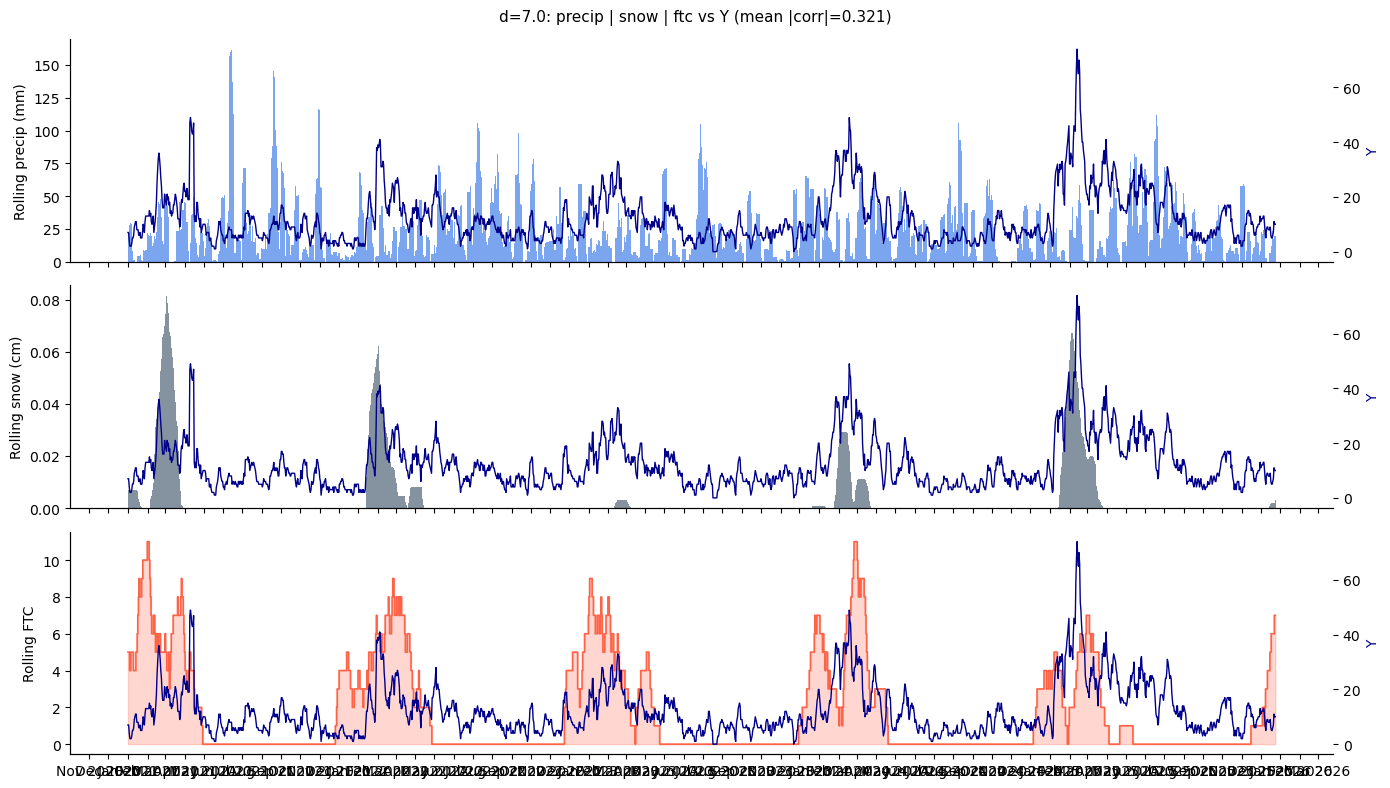

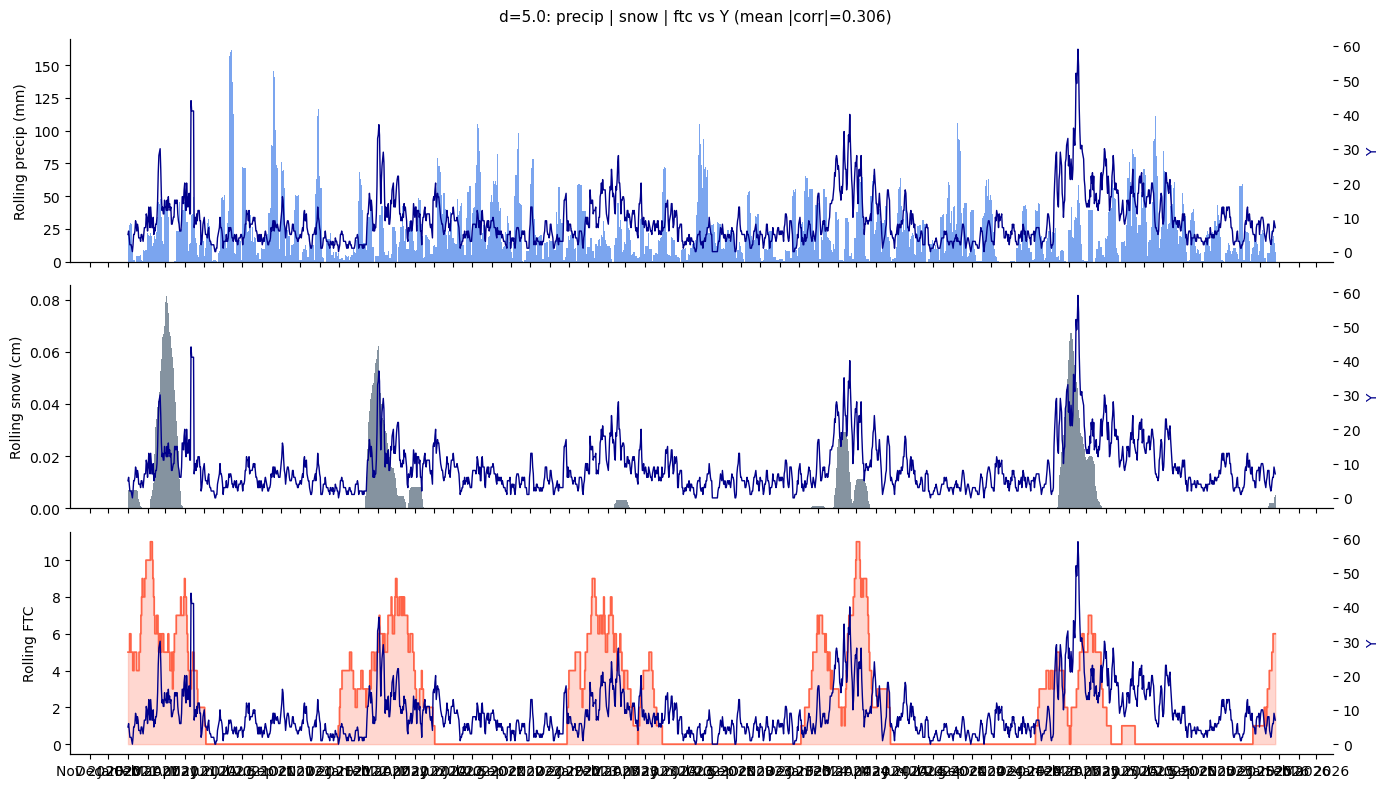

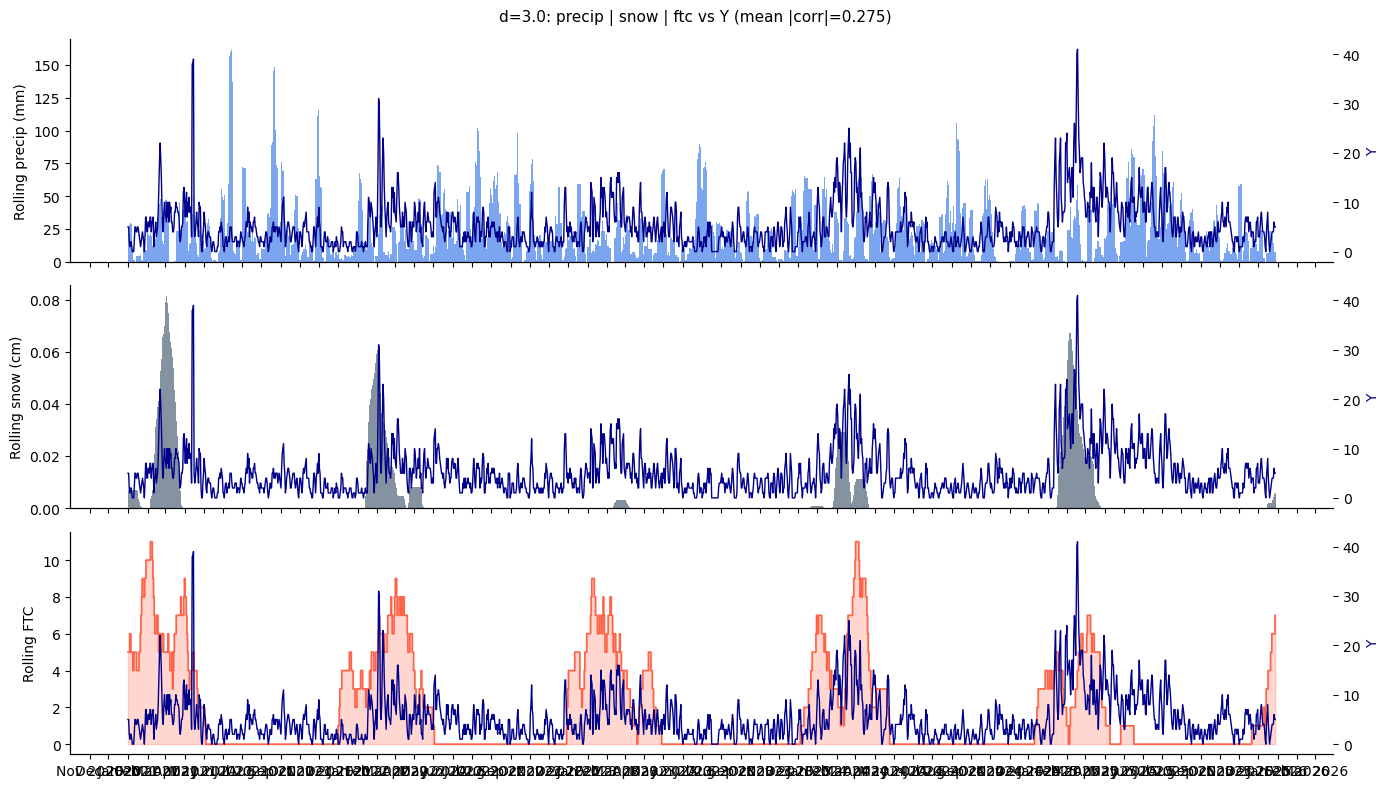

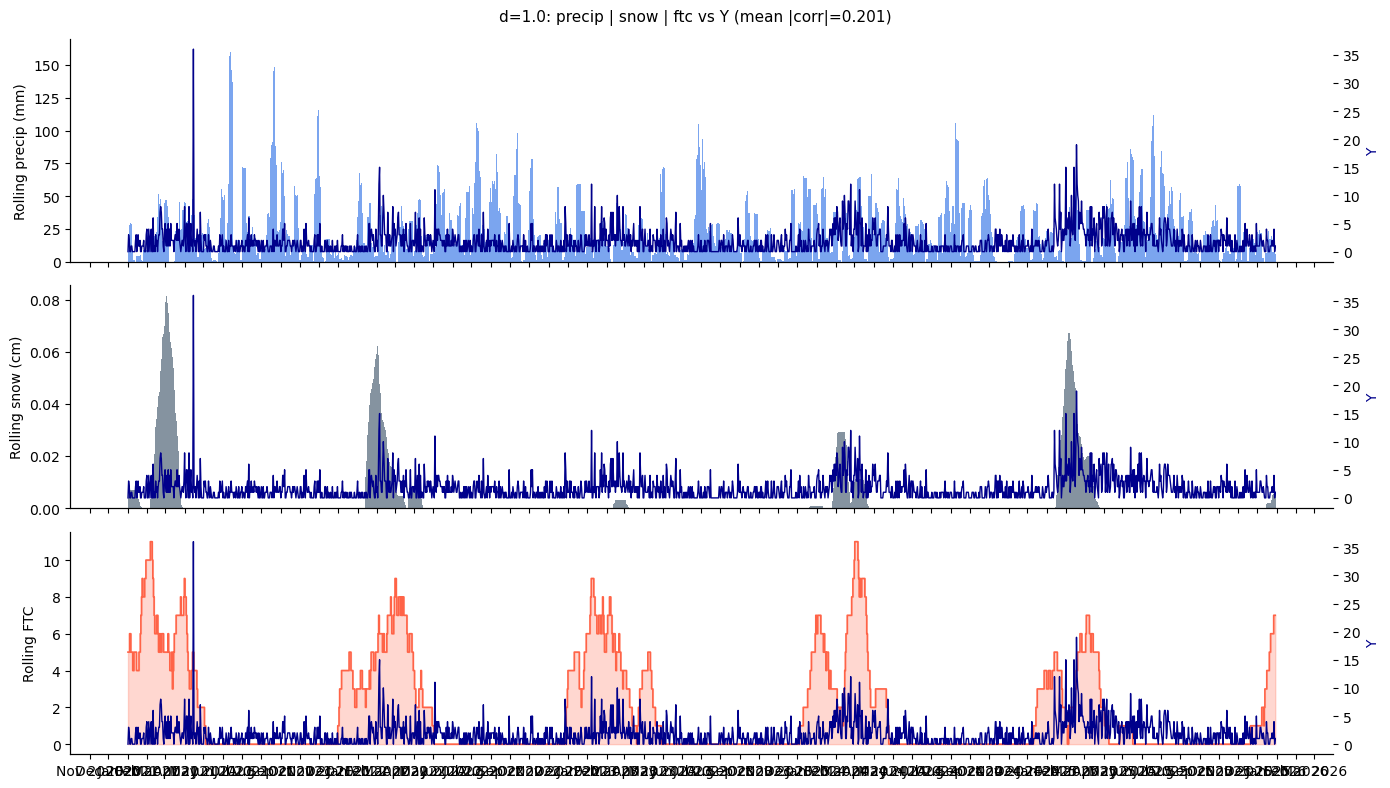

In [7]:
# Time-series plots: precip_roll, snow_roll, ftc_roll and Y over time (best params per d)
import matplotlib.dates as mdates

for i, (_, row) in enumerate(top1_per_d.iterrows()):
    params = {
        "d": int(row.d), "d_p": int(row.d_p), "l_p": int(row.l_p),
        "d_s": int(row.d_s), "l_s": int(row.l_s), "d_f": int(row.d_f), "l_f": int(row.l_f), "k_AR": int(row.k_AR),
    }
    feat_df = assemble_features(pothole_df, weather_df, params, verbose=False)
    feat_df["date_dt"] = pd.to_datetime(feat_df["date"])

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"d={row.d}: precip | snow | ftc vs Y (mean |corr|={row.mean_abs_corr:.3f})", fontsize=11)

    axes[0].bar(feat_df["date_dt"], feat_df["precip_roll"], color="cornflowerblue", width=1, alpha=0.85)
    axes[0].set_ylabel("Rolling precip (mm)")
    ax0_twin = axes[0].twinx()
    ax0_twin.plot(feat_df["date_dt"], feat_df["Y"], color="darkblue", linewidth=1)
    ax0_twin.set_ylabel("Y", color="darkblue")

    axes[1].bar(feat_df["date_dt"], feat_df["snow_roll"], color="slategray", width=1, alpha=0.85)
    axes[1].set_ylabel("Rolling snow (cm)")
    ax1_twin = axes[1].twinx()
    ax1_twin.plot(feat_df["date_dt"], feat_df["Y"], color="darkblue", linewidth=1)
    ax1_twin.set_ylabel("Y", color="darkblue")

    axes[2].step(feat_df["date_dt"], feat_df["ftc_roll"], color="tomato", linewidth=1.2, where="mid")
    axes[2].fill_between(feat_df["date_dt"], feat_df["ftc_roll"], step="mid", color="tomato", alpha=0.25)
    axes[2].set_ylabel("Rolling FTC")
    ax2_twin = axes[2].twinx()
    ax2_twin.plot(feat_df["date_dt"], feat_df["Y"], color="darkblue", linewidth=1)
    ax2_twin.set_ylabel("Y", color="darkblue")

    axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axes[2].xaxis.set_major_locator(mdates.MonthLocator())
    plt.tight_layout()
    plt.show()